코드 8-1 라이브러리 호출

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim

코드 8-2 데이터셋 내려받기

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
trainset = torchvision.datasets.FashionMNIST(
    root='../chap08/data/', train=True,
    download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.2MB/s]


코드 8-3 데이터셋을 메모리로 가져오기

In [5]:
batch_size = 4
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

코드 8-4 데이터셋 분리

In [7]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(images.shape)
print(images[0].shape)
print(labels[0].item())

torch.Size([4, 1, 28, 28])
torch.Size([1, 28, 28])
4


코드 8-5 이미지 데이터를 출력하기 위한 전처리

In [8]:
def imshow(img, title):
  plt.figure(figsize=(batch_size * 4, 4)) # 출력할 개별 이미지의 크기 지정
  plt.axis('off')
  plt.imshow(np.transpose(img, (1, 2, 0)))
  plt.title(title)
  plt.show()

코드 8-6 이미지 데이터 출력 함수

In [10]:
def show_batch_images(dataloader):
  images, labels = next(iter(dataloader)) # 이미지 크기는 (4,28,28,1)이 된다. (배치 크기, 높이, 너비, 채널)

  img = torchvision.utils.make_grid(images) # 좌표에 이미지 픽셀을 대응시켜 그리드 형태로 출력
  imshow(img, title=[str(x.item()) for x in labels]) # imshow 함수를 사용함으로써 데이터의 형태가 (채널, 높이, 너비)에서 (높이, 너비, 채널)로 변경됨

  return images, labels

코드 8-7 이미지 출력

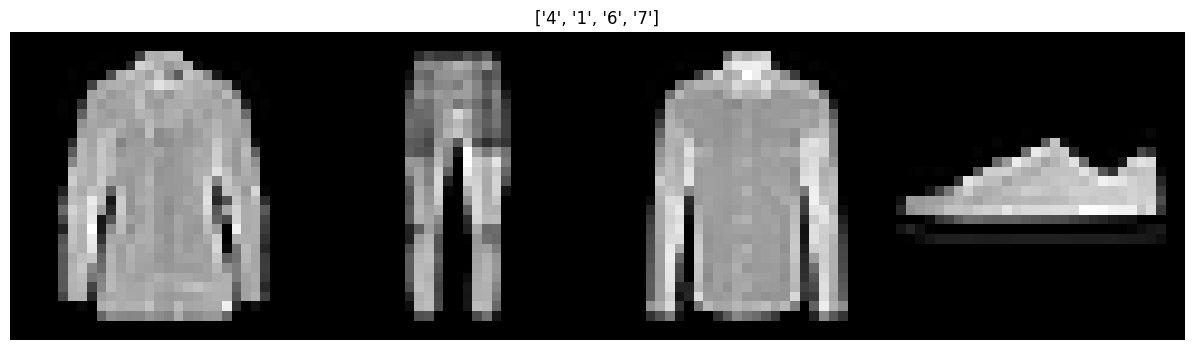

In [11]:
images, labels = show_batch_images(trainloader)

코드 8-8 배치 정규화가 적용되지 않은 네트워크

In [12]:
class NormalNet(nn.Module):
  def __init__(self):
    super(NormalNet, self).__init__()
    self.classifier = nn.Sequential(
        nn.Linear(784, 48), # (28,28) 크기의 이미지로 입력은 784(28x28) 크기가 된다.
        nn.ReLU(),
        nn.Linear(48, 24),
        nn.ReLU(),
        nn.Linear(24, 10) # FashionMNIST 클래스 10개
    ) # nn.Sequential을 사용하면 forward() 함수에서 계층별로 가독성 있게 코드 구현 가능

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.classifier(x) # nn.Sequential에서 정의한 계층 호출
    return x

코드 8-9 배치 정규화가 포함된 네트워크

In [13]:
class BNNet(nn.Module):
  def __init__(self):
    super(BNNet, self).__init__()
    self.classifier = nn.Sequential(
        nn.Linear(784, 48),
        nn.BatchNorm1d(48),
        nn.ReLU(),
        nn.Linear(48, 24),
        nn.BatchNorm1d(24),
        nn.ReLU(),
        nn.Linear(24, 10)
    )

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x

코드 8-10 배치 정규화가 적용되지 않은 모델 선언

In [14]:
model = NormalNet()
print(model)

NormalNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=10, bias=True)
  )
)


코드 8-11 배치 정규화가 적용된 모델 선언

In [15]:
model_bn = BNNet()
print(model_bn)

BNNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=10, bias=True)
  )
)


코드 8-12 데이터셋 메모리로 불러오기

In [16]:
batch_size = 512
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

코드 8-13 옵티마이저, 손실 함수 지정

In [17]:
loss_fn = nn.CrossEntropyLoss()
opt = optim.SGD(model.parameters(), lr=0.01)
opt_bn = optim.SGD(model_bn.parameters(), lr=0.01)

코드 8-14 모델 학습

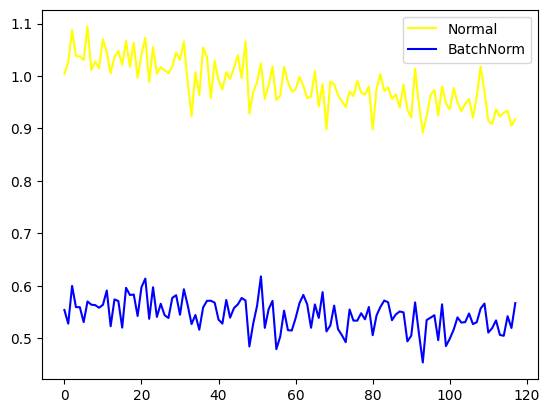

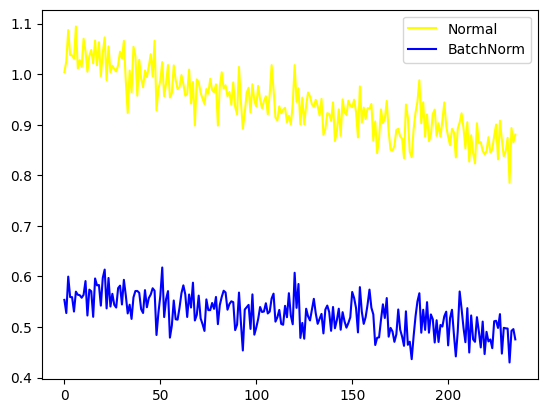

In [22]:
loss_arr = []
loss_bn_arr = []
max_epochs = 2

for epoch in range(max_epochs):
  for i, data in enumerate(trainloader, 0):
    inputs, labels = data
    opt.zero_grad() # 배치 정규화가 적용되지 않은 모델 학습
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    loss.backward()
    opt.step()

    opt_bn.zero_grad() # 배치 정규화가 적용된 모델 학습
    outputs_bn = model_bn(inputs)
    loss_bn = loss_fn(outputs_bn, labels)
    loss_bn.backward()
    opt_bn.step()

    loss_arr.append(loss.item())
    loss_bn_arr.append(loss_bn.item())

  plt.plot(loss_arr, 'yellow', label='Normal')
  plt.plot(loss_bn_arr, 'blue', label='BatchNorm')
  plt.legend()
  plt.show()

코드 8-15 데이터셋의 분포를 출력하기 위한 전처리

In [23]:
N = 50
noise = 0.3

x_train = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_train = x_train + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))

x_test = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_test = x_test + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))

코드 8-16 데이터 분포를 그래프로 출력

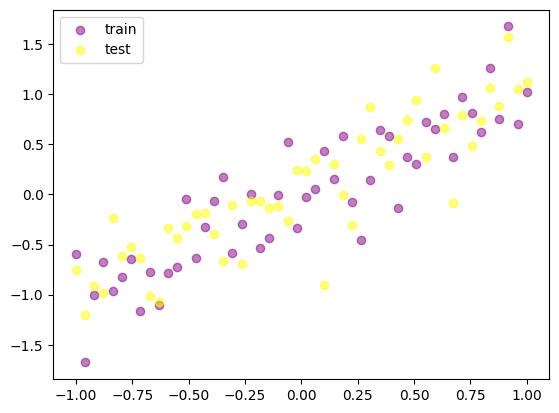

In [24]:
plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c='purple',
            alpha=0.5, label='train')
plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c='yellow',
            alpha=0.5, label='test')
plt.legend()
plt.show()

코드 8-17 드롭아웃을 위한 모델 생성

In [25]:
N_h = 100
model = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1),
    ) # 드롭아웃이 적용되지 않은 모델

model_dropout = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.Dropout(0.2), # 드롭아웃 적용
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1),
) # 드롭아웃이 적용된 모델

코드 8-18 옵티마이저와 손실 함수 지정

In [26]:
opt = torch.optim.Adam(model.parameters(), lr=0.01)
opt_dropout = torch.optim.Adam(model_dropout.parameters(), lr=0.01)
loss_fn = torch.nn.MSELoss()

코드 8-19 모델 학습

/tmp/ipykernel_2306/2616464378.py:33: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.title('Epoch %d, Loss=%0.4f, Loss with dropout=%0.4f' %


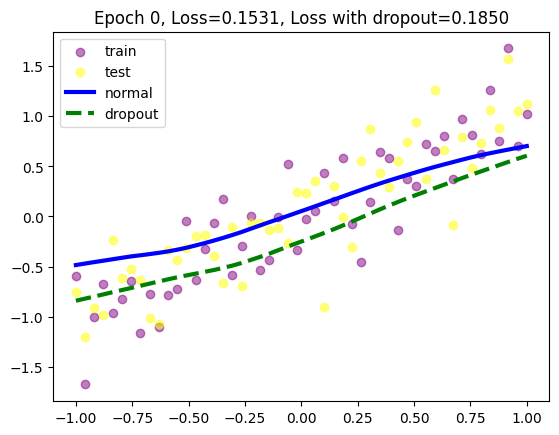

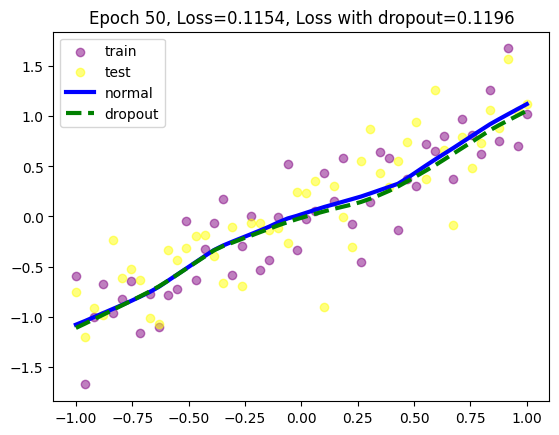

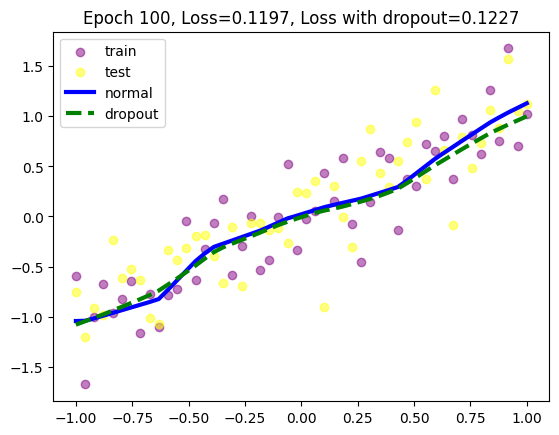

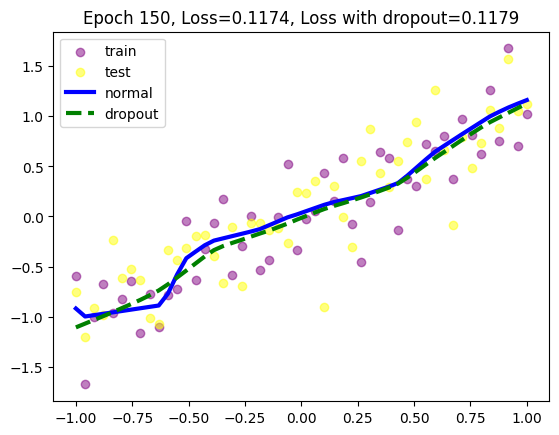

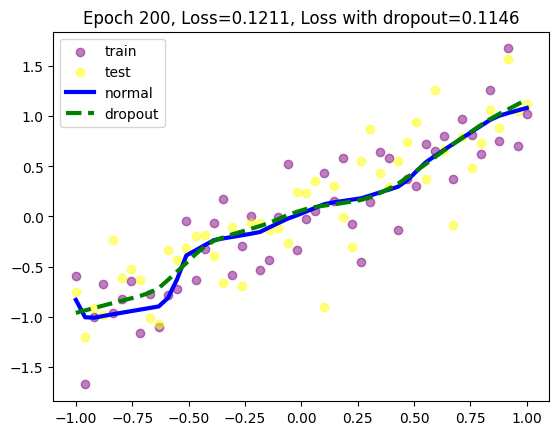

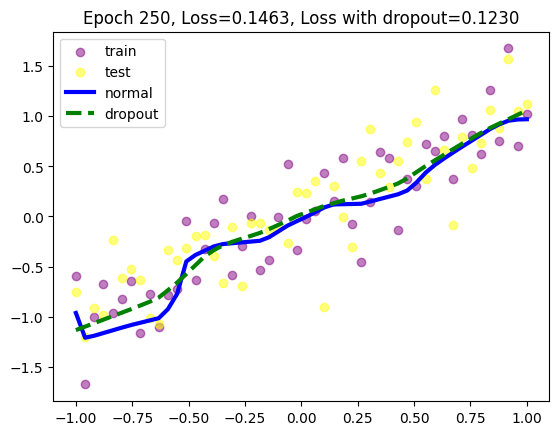

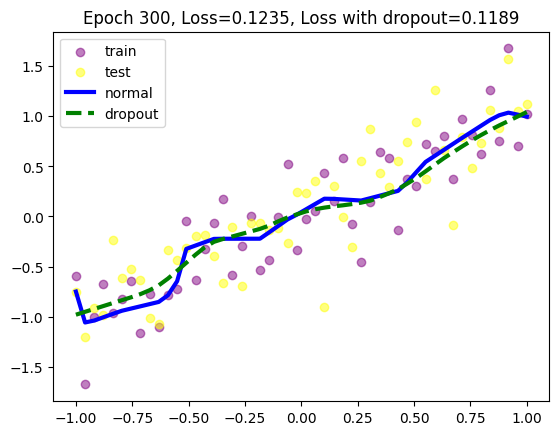

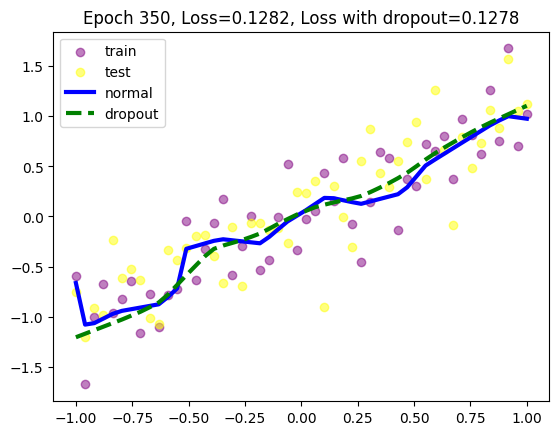

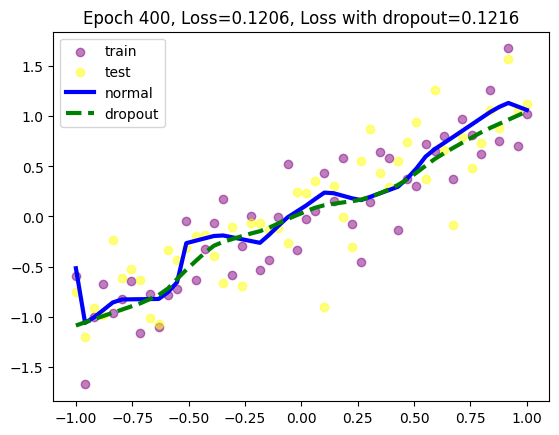

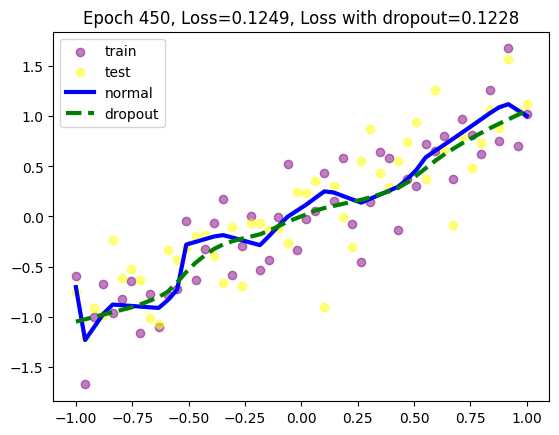

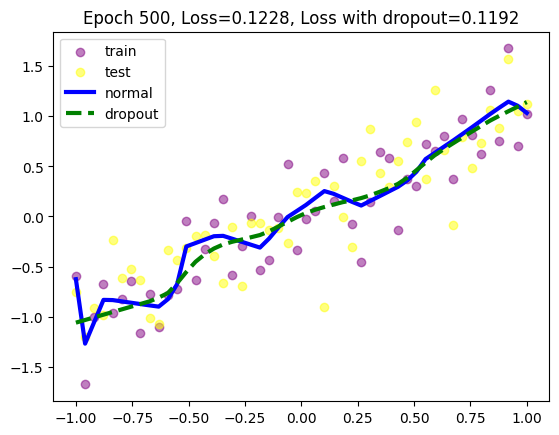

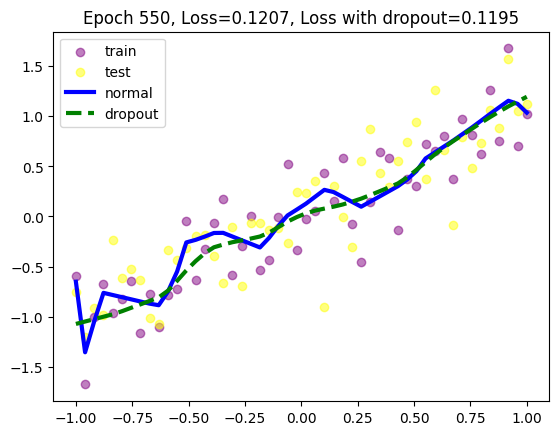

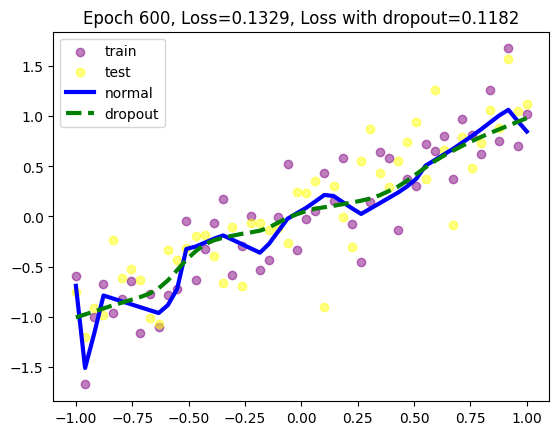

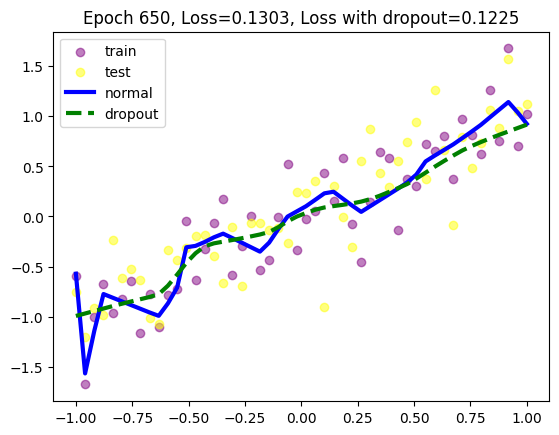

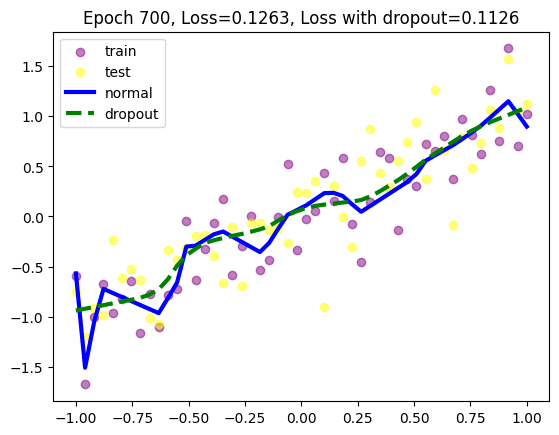

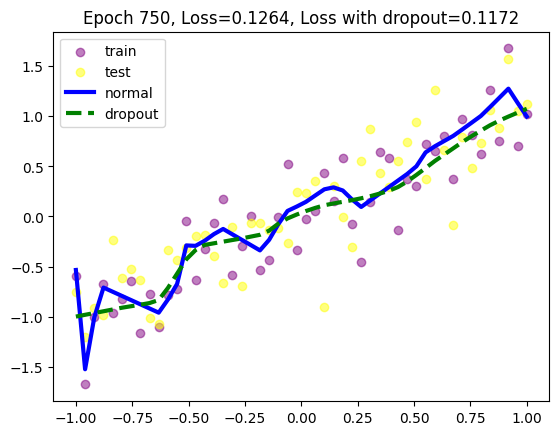

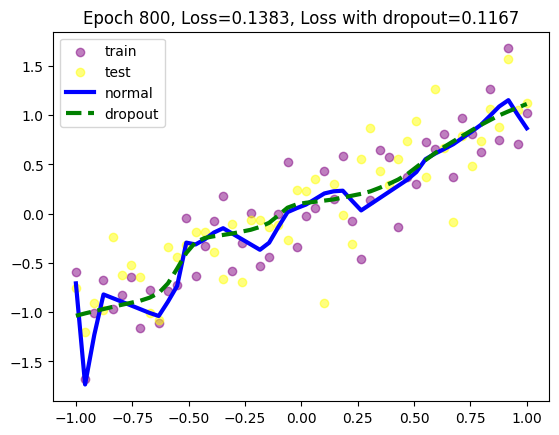

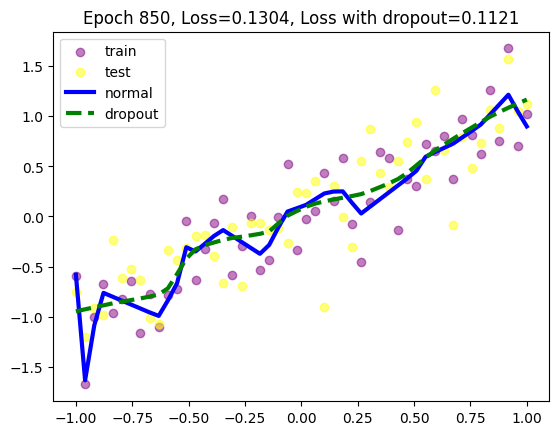

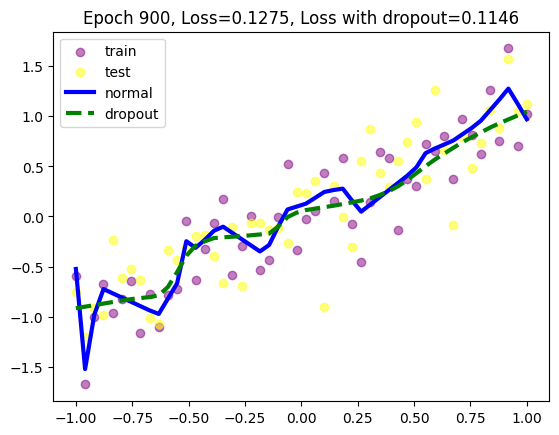

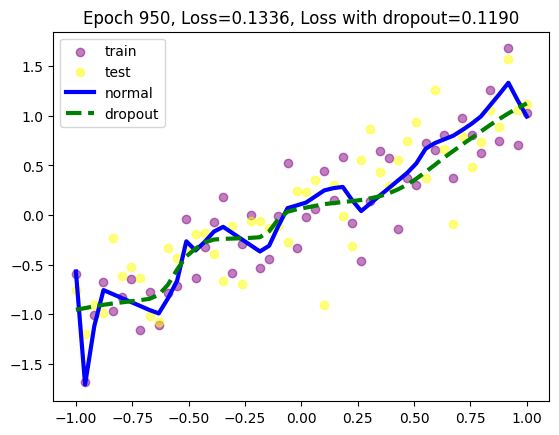

In [27]:
max_epochs = 1000
for epoch in range(max_epochs):
  pred = model(x_train) # 드롭아웃이 적용되지 않은 모델 학습
  loss = loss_fn(pred, y_train)
  opt.zero_grad()
  loss.backward()
  opt.step()

  pred_dropout = model_dropout(x_train) # 드롭아웃이 적용된 모델 학습
  loss_dropout = loss_fn(pred_dropout, y_train)
  opt_dropout.zero_grad()
  loss_dropout.backward()
  opt_dropout.step()

  if epoch % 50 == 0: # epoch를 50으로 나눈 나머지가 0이면 다음 진행
    model.eval()
    model_dropout.eval()

    test_pred = model(x_test)
    test_loss = loss_fn(test_pred, y_test)

    test_pred_dropout = model_dropout(x_test)
    test_loss_dropout = loss_fn(test_pred_dropout, y_test)

    plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c='purple',
                alpha=0.5, label='train')
    plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c='yellow',
                alpha=0.5, label='test')
    plt.plot(x_test.data.numpy(), test_pred.data.numpy(), 'b-', lw=3,
             label='normal') # 파란색 실선으로 x축은 테스트 데이터셋, y축은 드롭아웃이 적용되지 않은 모델의 결과를 그래프로 출력
    plt.plot(x_test.data.numpy(), test_pred_dropout.data.numpy(), 'g--', lw=3,
             label='dropout') # 초록색 점선으로 x축은 테스트 데이터셋, y축은 드롭아웃이 적용된 모델의 결과를 그래프로 출력
    plt.title('Epoch %d, Loss=%0.4f, Loss with dropout=%0.4f' %
              (epoch, test_loss, test_loss_dropout)) # 에포크, 드롭아웃이 적용되지 않은 모델의 오차, 드롭아웃이 적용된 모델의 오차를 타이틀로 출력
    plt.legend()
    model.train()
    model_dropout.train()
    plt.pause(0.05)

코드 8-20 라이브러리 호출

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models # 사전 학습된 모델 이용
from torchvision import transforms, datasets

import matplotlib
import matplotlib.pyplot as plt
import time
import argparse
from tqdm import tqdm
matplotlib.style.use('ggplot') # 출력 그래프에서 격자로 숫자 범위가 눈에 잘 띄도록 하는 스타일
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

코드 8-21 데이터셋 전처리

In [15]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

코드 8-22 데이터셋 가져오기

In [17]:
train_dataset = datasets.ImageFolder(
    root='/content/drive/MyDrive/chap08/data//archive/train',
    transform=train_transform
)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True,
)
val_dataset = datasets.ImageFolder(
    root=r'/content/drive/MyDrive/chap08/data//archive/test',
    transform=val_transform
)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size=32, shuffle=False,
)

코드 8-23 모델 생성

In [20]:
def resnet50(pretrained=True, requires_grad=False):
  model = models.resnet50(progress=True, pretrained=pretrained)
  if requires_grad == False: # 파라미터 고정하여 backward() 중에 기울기가 계산되지 않도록 함
    for param in model.parameters(): # requires_grad=False를 파라미터로 받았기 때문에 해당 구문이 실행됨
      param.requires_grad = False
  elif requires_grad == True: # 파라미터 값이 backward() 중에 기울기 계산에 반영됨
    for param in model.parameters():
      param.requires_grad = True
  model.fc = nn.Linear(2048, 2) # 마지막 분류를 위한 계층은 학습 진행
  return model

코드 8-24 학습률 감소

In [21]:
class LRScheduler():
  def __init__(
      self, optimizer, patience=5, min_lr=1e-6, factor=0.5
  ):
    self.optimizer = optimizer
    self.patience = patience
    self.min_lr = min_lr
    self.factor = factor
    self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        self.optimizer,
        mode='min',
        patience=self.patience,
        factor=self.factor,
        min_lr=self.min_lr,
        verbose=True
    ) # 1.
  def __call__(self, val_loss):
    self.lr_scheduler.step(val_loss) # 2.

코드 8-25 조기 종료

In [24]:
class EarlyStopping():
  def __init__(self, patience=5, verbose=False, delta=0,
               path='/content/drive/MyDrive/chap08/data/checkpoint.pt'):
    self.patience = patience # 1.
    self.verbose = verbose
    self.counter = 0
    self.best_score = None # 검증 데이터셋에 대한 오차 최적화값
    self.early_stop = False # 조기 종료 의미
    self.val_loss_min = np.Inf # 무한대 표현
    self.delta = delta # 2.
    self.path = path # 모델이 저장될 경로

  def __call__(self, val_loss, model):
    score = -val_loss
    if self.best_score is None:
      self.best_score = score
      self.save_checkpoint(val_loss, model)
    elif score < self.best_score + self.delta:
      self.counter  += 1
      print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
      if self.counter >= self.patience:
        self.early_stop = True
      else:
        self.best_score = score
        self.save_checkpoint(val_loss, model)
        self.counter = 0

  def save_checkpoint(self, val_loss, model):
    if self.verbose:
      print(f'Validation loss decreased ({self.val_loss_min: .6f} --> {val_loss: .6f}). Saving model...')
    torch.save(model.state_dict(), self.path)
    self.val_loss_min = val_loss

코드 8-26 인수 값 지정

In [27]:
parser = argparse.ArgumentParser()
parser.add_argument('--lr-scheduler', dest='lr_scheduler', action='store_true')
parser.add_argument('--early-stopping', dest='early_stopping', action='store_true')
args = vars(parser.parse_args([]))

코드 8-27 사전 훈련된 모델의 파라미터 확인

In [29]:
print(f"Computation device: {device}\n")
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)
print(f"{total_trainable_params:,} training parametes.")

Computation device: cuda:0

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 194MB/s]


25,557,032 total parameters.
25,557,032 training parametes.


코드 8-28 옵티마이저와 손실 함수 지정

In [30]:
lr = 0.001
epochs = 100
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

코드 8-29 오차, 정확도 및 모델의 이름에 대한 문자열

In [37]:
loss_plot_name = 'loss'
acc_plot_name = 'accuracy'
model_name = 'model'

코드 8-30 오차, 정확도 및 모델의 이름에 대한 문자열

In [32]:
if args['lr_scheduler']:
  print('INFO: Initializing learning rate scheduler')
  lr_scheduler = LRScheduler(optimizer)
  loss_plot_name = 'lrs_loss'
  acc_plot_name = 'lrs_accuracy'
  model_name = 'lrs_model'
if args['early_stopping']:
  print('INFO: Initializing early stopping')
  early_stopping = EarlyStopping()
  loss_plot_name = 'es_loss'
  acc_plot_name = 'es_accuracy'
  model_name = 'es_model'

코드 8-31 모델 학습 함수

In [33]:
def training(model, train_dataloader, train_dataset, optimizer, criterion):
  print('Training')
  model.train()
  train_running_loss = 0.0
  train_running_correct = 0
  counter = 0
  total = 0
  prog_bar = tqdm(enumerate(train_dataloader), total=int(len(train_dataset)/
                                                         train_dataloader.batch_size))
  for i, data in prog_bar:
    counter += 1
    data, target = data[0].to(device), data[1].to(device)
    total += target.size(0)
    optimizer.zero_grad()
    outputs = model(data)
    loss = criterion(outputs, target)
    train_running_loss += loss.item()
    _, preds = torch.max(outputs.data, 1)
    train_running_correct += (preds == target).sum().item()
    loss.backward()
    optimizer.step()

  train_loss = train_running_loss / counter
  train_accuracy = 100. * train_running_correct / total
  return train_loss, train_accuracy

코드 8-32 모델 검증 함수

In [34]:
def validate(model, test_dataloader, val_dataset, criterion):
  print('Validating')
  model.eval()
  val_running_loss = 0.0
  val_running_correct = 0
  counter = 0
  total = 0
  prog_bar = tqdm(enumerate(test_dataloader), total=int(len(val_dataset)/
                                                         test_dataloader.batch_size))
  with torch.no_grad():
    for i, data in prog_bar:
      counter += 1
      data, target = data[0].to(device), data[1].to(device)
      total += target.size(0)
      outputs = model(data)
      loss = criterion(outputs, target)

      val_running_loss += loss.item()
      _, preds = torch.max(outputs.data, 1)
      val_running_correct += (preds == target).sum().item()

    val_loss = val_running_loss / counter
    val_accuracy = 100. * val_running_correct / total
    return val_loss, val_accuracy

코드 8-33 모델 학습

In [35]:
train_loss, train_accuracy = [], []

val_loss, val_accuracy = [], []

start = time.time()
for epoch in range(epochs):
  print(f"Epoch {epoch+1} of {epochs}")
  train_epoch_loss, train_epoch_accuracy = training(model, train_dataloader, train_dataset, optimizer, criterion)
  val_epoch_loss, val_epoch_accuracy = validate(model, val_dataloader, val_dataset, criterion)
  train_loss.append(train_epoch_loss)
  train_accuracy.append(train_epoch_accuracy)
  val_loss.append(val_epoch_loss)
  val_accuracy.append(val_epoch_accuracy)
  if args['lr_scheduler']:
    lr_scheduler(val_epoch_loss)
  if args['early_stopping']:
    early_stopping(val_epoch_loss, model)
    if early_stopping.early_stop:
      break
  print(f"Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.2f}")
  print(f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.2f}")
end = time.time()
print(f"Training time: {(end-start)/60:.3f} minutes")

Epoch 1 of 100
Training


16it [03:30, 13.18s/it]


Validating


16it [03:25, 12.82s/it]


Train Loss: 1.9309, Train Acc: 55.82
Val Loss: 0.5310, Val Acc: 73.80
Epoch 2 of 100
Training


...

Train Loss: 0.1122, Train Acc: 96.18
Val Loss: 2.4965, Val Acc: 62.00
Epoch 100 of 100
Training


16it [00:06,  2.63it/s]


Validating


16it [00:05,  3.10it/s]

Train Loss: 0.1230, Train Acc: 94.98
Val Loss: 1.6357, Val Acc: 73.60
Training time: 25.573 minutes


코드 8-34 모델 학습 결과 출력

Saving loss and accuracy plots...


FileNotFoundError: [Errno 2] No such file or directory: '../chap08/img/accuracy.png'

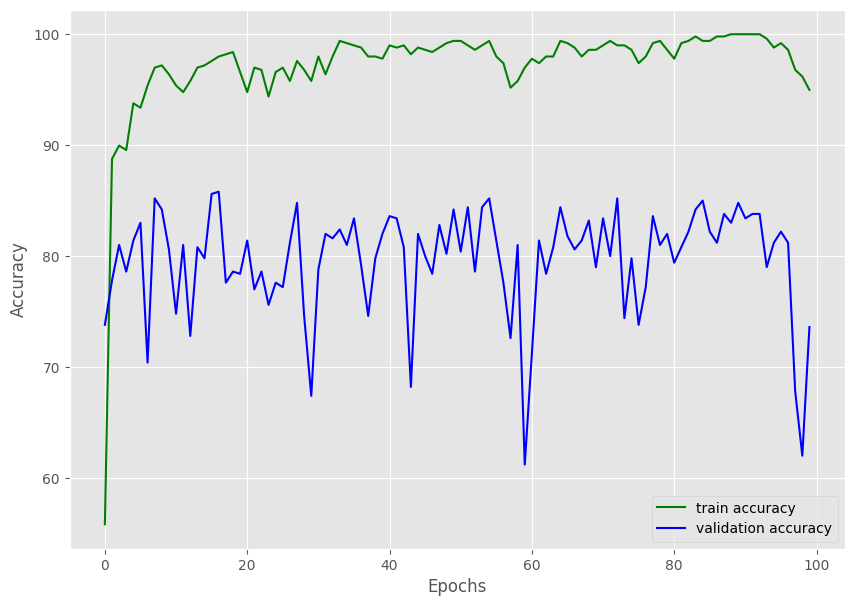

In [38]:
print('Saving loss and accuracy plots...')
plt.figure(figsize=(10,7))
plt.plot(train_accuracy, color='green', label='train accuracy')
plt.plot(val_accuracy, color = 'blue', label='validation accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig(f"../chap08/img/{acc_plot_name}.png")
plt.show()
plt.figure(figsize=(10,7))
plt.plot(train_loss, color='orange', label='train loss')
plt.plot(val_loss, color='red', label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f"../chap08/img/{loss_plot_name}.png")
plt.show()

print('Saving model...')
torch.save(model.state_dict(), f"../chap08/model/{model_name}.pth")
print('TRAINING COMPLETE')